In [1]:
# ViT-Tiny with frozen backbone + D4 symmetry augmentation.
# Only train the classification head (193 params).
# Train with random 90/180/270 rotation + flips + color jitter. Test on 0/90/180/270.

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

DATA_DIR = r"E:\Deep Learning Spring 26\dataset"
BATCH_SIZE = 32
EPOCHS = 6
LR = 1e-3
NUM_WORKERS = 0
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
train_dir = os.path.join(DATA_DIR, "train")
df = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df.label, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df.label, random_state=SEED)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 176020  |  Val: 22002  |  Test: 22003


In [3]:
# D4 symmetry augmentation: random 90-degree rotations + flips + color jitter
train_transform = transforms.Compose([
    transforms.RandomChoice([
        transforms.Lambda(lambda img: img),
        transforms.Lambda(lambda img: img.rotate(90)),
        transforms.Lambda(lambda img: img.rotate(180)),
        transforms.Lambda(lambda img: img.rotate(270)),
    ]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# eval: just normalize, no augmentation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CancerDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, rotation=0):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.rotation = rotation
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row.id + ".tif")).convert("RGB")
        if self.rotation != 0:
            img = img.rotate(self.rotation)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row.label, dtype=torch.float32)

In [4]:
train_loader = DataLoader(CancerDataset(train_df, train_dir, train_transform, rotation=0),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(CancerDataset(val_df, train_dir, eval_transform, rotation=0),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_loaders = {}
for angle in [0, 90, 180, 270]:
    test_loaders[angle] = DataLoader(
        CancerDataset(test_df, train_dir, eval_transform, rotation=angle),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [5]:
# ViT-Tiny: 5.7M params, 12 layers, 3 heads, 192-dim embeddings
# img_size=96 gives us 6x6=36 patches instead of 14x14=196
model = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=1, img_size=96)

# freeze everything except the head
for name, param in model.named_parameters():
    if "head" not in name:
        param.requires_grad = False
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {num_params:,}")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Trainable params: 193


In [6]:
def train_one_epoch():
    model.train()
    total_loss = 0
    preds_list, labels_list = [], []
    for imgs, labels in tqdm(train_loader, desc="Training", leave=False):
        imgs = imgs.to(device)
        labels = labels.unsqueeze(1).to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds_list.extend(torch.sigmoid(out).squeeze().detach().cpu().numpy())
        labels_list.extend(labels.squeeze().cpu().numpy())
    avg_loss = total_loss / len(train_loader)
    p, l = np.array(preds_list), np.array(labels_list).astype(int)
    b = (p >= 0.5).astype(int)
    return avg_loss, accuracy_score(l, b), f1_score(l, b, average="weighted"), roc_auc_score(l, p)

def evaluate(loader):
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds_list.extend(torch.sigmoid(model(imgs)).squeeze().cpu().numpy())
            labels_list.extend(labels.numpy())
    p, l = np.array(preds_list), np.array(labels_list).astype(int)
    b = (p >= 0.5).astype(int)
    return accuracy_score(l, b), f1_score(l, b, average="weighted"), roc_auc_score(l, p)

In [7]:
best_auc = 0.0
for epoch in range(1, EPOCHS + 1):
    loss, train_acc, train_f1, train_auc = train_one_epoch()
    scheduler.step()
    val_acc, val_f1, val_auc = evaluate(val_loader)

    lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch}/{EPOCHS} (lr={lr:.2e})")
    print(f"  Train  =>  Loss: {loss:.4f}  Acc: {train_acc:.4f}  F1: {train_f1:.4f}  AUC: {train_auc:.4f}")
    print(f"  Val    =>  Acc: {val_acc:.4f}  F1: {val_f1:.4f}  AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_vit_frozen_d4.pth")
        print(f"  >> Saved best model (AUC={val_auc:.4f})")


Epoch 1/6 (lr=9.33e-04)
  Train  =>  Loss: 0.4437  Acc: 0.7961  F1: 0.7949  AUC: 0.8677
  Val    =>  Acc: 0.8175  F1: 0.8151  AUC: 0.8931
  >> Saved best model (AUC=0.8931)



Epoch 2/6 (lr=7.50e-04)
  Train  =>  Loss: 0.4359  Acc: 0.7999  F1: 0.7989  AUC: 0.8731
  Val    =>  Acc: 0.8182  F1: 0.8145  AUC: 0.8881



Epoch 3/6 (lr=5.00e-04)
  Train  =>  Loss: 0.4345  Acc: 0.8023  F1: 0.8013  AUC: 0.8737
  Val    =>  Acc: 0.8198  F1: 0.8169  AUC: 0.8925



Epoch 4/6 (lr=2.50e-04)
  Train  =>  Loss: 0.4302  Acc: 0.8037  F1: 0.8027  AUC: 0.8763
  Val    =>  Acc: 0.8138  F1: 0.8146  AUC: 0.8937
  >> Saved best model (AUC=0.8937)



Epoch 5/6 (lr=6.70e-05)
  Train  =>  Loss: 0.4278  Acc: 0.8048  F1: 0.8037  AUC: 0.8777
  Val    =>  Acc: 0.8064  F1: 0.8079  AUC: 0.8929



Epoch 6/6 (lr=0.00e+00)
  Train  =>  Loss: 0.4258  Acc: 0.8062  F1: 0.8051  AUC: 0.8788
  Val    =>  Acc: 0.8158  F1: 0.8164  AUC: 0.8940
  >> Saved best model (AUC=0.8940)


In [8]:
print("\nRotation test (best model):")
model.load_state_dict(torch.load("best_vit_frozen_d4.pth"))
for angle in [0, 90, 180, 270]:
    acc, f1, auc = evaluate(test_loaders[angle])
    print(f"  {angle:3d}°  =>  Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")


Rotation test (best model):


C:\Users\AhmedFahmy\AppData\Local\Temp\ipykernel_20744\2943510906.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_vit_frozen_d4.pt

    0°  =>  Acc: 0.8166  F1: 0.8171  AUC: 0.8933
   90°  =>  Acc: 0.8182  F1: 0.8189  AUC: 0.8955
  180°  =>  Acc: 0.8150  F1: 0.8157  AUC: 0.8939
  270°  =>  Acc: 0.8158  F1: 0.8166  AUC: 0.8945


## Confusion Matrix & Recall

Confusion matrix for the 0° test set. Recall is the most important metric here — a missed cancer (low recall) is far more dangerous than a false alarm.

In [9]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# get predictions at 0°
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loaders[0], desc="Predicting", leave=False):
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

probs_0 = np.array(all_probs)
labels = np.array(all_labels).astype(int)
preds_0 = (probs_0 >= 0.5).astype(int)

cm = confusion_matrix(labels, preds_0)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print()
print(f"Accuracy:  {accuracy_score(labels, preds_0):.4f}")
print(f"Recall:    {recall_score(labels, preds_0):.4f}")
print(f"Precision: {precision_score(labels, preds_0):.4f}")
print(f"F1:        {f1_score(labels, preds_0, average='weighted'):.4f}")
print(f"AUC:       {roc_auc_score(labels, probs_0):.4f}")

Confusion Matrix:
  TN=10902  FP=2189
  FN=1846  TP=7066

Accuracy:  0.8166
Recall:    0.7929
Precision: 0.7635
F1:        0.8171
AUC:       0.8933


Confusion matrix heatmap.

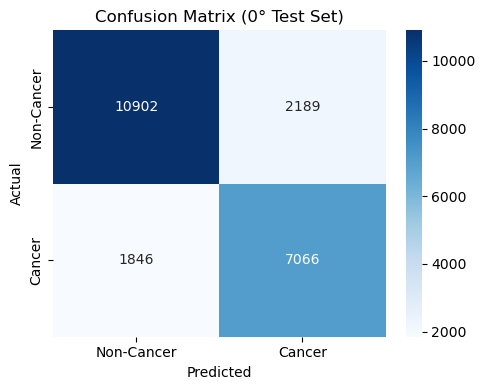

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (0° Test Set)")
plt.tight_layout()
plt.show()

## Flip Rate Analysis

The flip rate measures how many diagnoses change when the same image is tested at a different rotation. For each test sample, we compare the 0° prediction to the rotated prediction. If they disagree, that's a flip.

We also break down flips by direction:
- Cancer → Non-Cancer: the model caught it at 0° but missed it when rotated (dangerous)
- Non-Cancer → Cancer: the model missed it at 0° but flagged it when rotated

In [11]:
rotated_preds = {}
rotated_probs = {}

for angle in [90, 180, 270]:
    all_probs, all_labels_r = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loaders[angle], desc=f"{angle}°", leave=False):
            imgs = imgs.to(device)
            probs = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
            all_probs.extend(probs)
    rotated_probs[angle] = np.array(all_probs)
    rotated_preds[angle] = (rotated_probs[angle] >= 0.5).astype(int)

print("Flip Rate Analysis:")
print()
for angle in [90, 180, 270]:
    flipped = (preds_0 != rotated_preds[angle])
    flip_rate = flipped.mean() * 100
    cancer_to_non = ((preds_0 == 1) & (rotated_preds[angle] == 0)).sum()
    non_to_cancer = ((preds_0 == 0) & (rotated_preds[angle] == 1)).sum()

    print(f"  {angle:3d}°: {flipped.sum()} / {len(flipped)} flipped  =>  Flip Rate = {flip_rate:.2f}%")
    print(f"       Cancer->Non-Cancer: {cancer_to_non}   Non-Cancer->Cancer: {non_to_cancer}")

flip_rates = []
for angle in [90, 180, 270]:
    flipped = (preds_0 != rotated_preds[angle])
    flip_rates.append(flipped.mean() * 100)
print(f"\nAverage Flip Rate: {np.mean(flip_rates):.2f}%")

Flip Rate Analysis:

   90°: 2215 / 22003 flipped  =>  Flip Rate = 10.07%
       Cancer->Non-Cancer: 1020   Non-Cancer->Cancer: 1195
  180°: 2145 / 22003 flipped  =>  Flip Rate = 9.75%
       Cancer->Non-Cancer: 1020   Non-Cancer->Cancer: 1125
  270°: 2189 / 22003 flipped  =>  Flip Rate = 9.95%
       Cancer->Non-Cancer: 1012   Non-Cancer->Cancer: 1177

Average Flip Rate: 9.92%


## Per-Angle Summary

Everything in one table: accuracy, recall, AUC, and flip rate for each angle.

In [12]:
print(f"{'Angle':>5s}  {'Acc':>7s}  {'Recall':>7s}  {'AUC':>7s}  {'Flip %':>7s}")
print(f"{'-----':>5s}  {'------':>7s}  {'------':>7s}  {'------':>7s}  {'------':>7s}")
print(f"{'0°':>5s}  {accuracy_score(labels, preds_0):7.4f}  {recall_score(labels, preds_0):7.4f}  {roc_auc_score(labels, probs_0):7.4f}  {'  ---':>7s}")

for angle in [90, 180, 270]:
    acc = accuracy_score(labels, rotated_preds[angle])
    rec = recall_score(labels, rotated_preds[angle])
    auc = roc_auc_score(labels, rotated_probs[angle])
    fr = ((preds_0 != rotated_preds[angle]).mean() * 100)
    print(f"{angle:>4d}°  {acc:7.4f}  {rec:7.4f}  {auc:7.4f}  {fr:6.2f}%")

Angle      Acc   Recall      AUC   Flip %
-----   ------   ------   ------   ------
   0°   0.8166   0.7929   0.8933      ---
  90°   0.8182   0.8046   0.8955   10.07%
 180°   0.8150   0.7968   0.8939    9.75%
 270°   0.8158   0.8012   0.8945    9.95%


## Visualizations

Flip rate, accuracy, and recall across rotation angles.

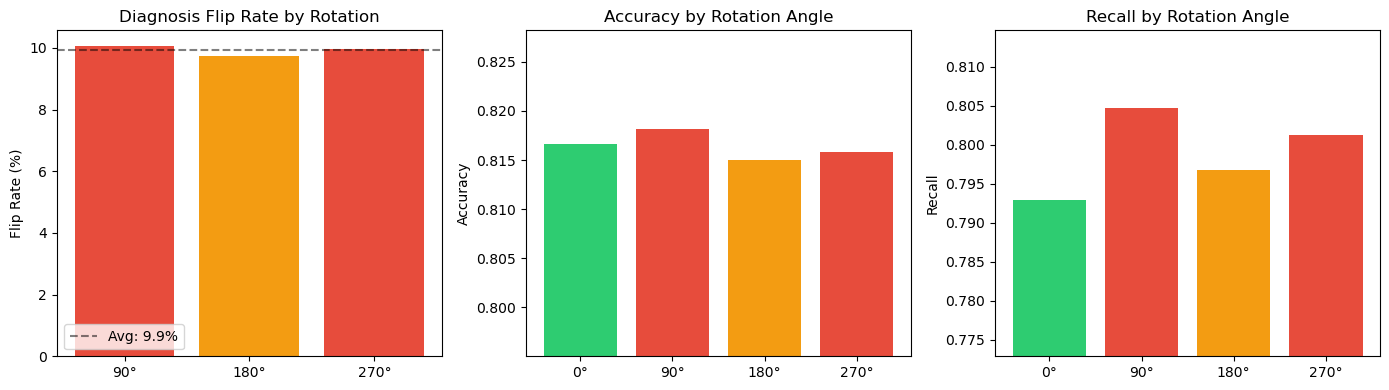

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

angles_list = [90, 180, 270]
fr_list = [((preds_0 != rotated_preds[a]).mean() * 100) for a in angles_list]
acc_list = [accuracy_score(labels, rotated_preds[a]) for a in angles_list]
rec_list = [recall_score(labels, rotated_preds[a]) for a in angles_list]

avg_fr = np.mean(fr_list)
acc_0 = accuracy_score(labels, preds_0)
rec_0 = recall_score(labels, preds_0)

# flip rate
axes[0].bar(["90°", "180°", "270°"], fr_list, color=["#e74c3c", "#f39c12", "#e74c3c"])
axes[0].set_ylabel("Flip Rate (%)")
axes[0].set_title("Diagnosis Flip Rate by Rotation")
axes[0].axhline(y=avg_fr, color="black", linestyle="--", alpha=0.5, label=f"Avg: {avg_fr:.1f}%")
axes[0].legend()

# accuracy
axes[1].bar(["0°", "90°", "180°", "270°"], [acc_0] + acc_list,
            color=["#2ecc71", "#e74c3c", "#f39c12", "#e74c3c"])
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy by Rotation Angle")
axes[1].set_ylim(min([acc_0]+acc_list) - 0.02, max([acc_0]+acc_list) + 0.01)

# recall
axes[2].bar(["0°", "90°", "180°", "270°"], [rec_0] + rec_list,
            color=["#2ecc71", "#e74c3c", "#f39c12", "#e74c3c"])
axes[2].set_ylabel("Recall")
axes[2].set_title("Recall by Rotation Angle")
axes[2].set_ylim(min([rec_0]+rec_list) - 0.02, max([rec_0]+rec_list) + 0.01)

plt.tight_layout()
plt.show()